# Model comparison: nested-LOSO out-of-fold predictions

Here we bring together the nested Leave-One-Subject-Out (LOSO) out-of-fold predictions from the
two models trained separately in `logistic_regression_training.ipynb` and `ANN_training.ipynb`.
Each of those notebooks saves its pooled out-of-fold predictions (`oof_true`, `oof_pred`,
`oof_proba`) and per-individual fold metrics to a `.npz` file (`results_logreg.npz`,
`results_ann.npz`), which is what we load below.

Every one of the 168 rows has exactly one out-of-fold prediction from a model that never saw that
individual during training or tuning, so these are honest held-out predictions for every
individual - that's what lets us actually compare which model generalizes better to a new person.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
)

sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

result_files = {
    "Logistic Regression": "results_logreg.npz",
    "ANN": "results_ann.npz",
}

results = {name: dict(np.load(fname, allow_pickle=True)) for name, fname in result_files.items()}
list(results["ANN"].keys())

['model_name',
 'oof_true',
 'oof_pred',
 'oof_proba',
 'fold_individual',
 'fold_accuracy',
 'fold_balanced_accuracy']

## Where does the threshold of 3 come from?

To turn the self-reported frustration scores (0-8) into a binary label, we needed a cutoff: below
it counts as "not frustrated," at or above it counts as "frustrated." Rather than just picking a
number, we looked at how the average score moves across the three experimental phases (rest,
active puzzle-solving, recovery) to see if a natural cutoff falls out of the data.

The plot below computes the mean frustration score per phase across the whole dataset.

AVERAGE FRUSTRATION SCORES PER PHASE
Phase 1: Rest (Baseline): 1.21
Phase 2: Task (Puzzle): 3.77
Phase 3: Recovery (Post-Task): 1.89


/var/folders/rt/wbb4_wsn7wbcjd1mmp6slq000000gn/T/ipykernel_40908/2168227742.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_means = df.groupby('Phase')['Frustrated'].mean().reset_index()


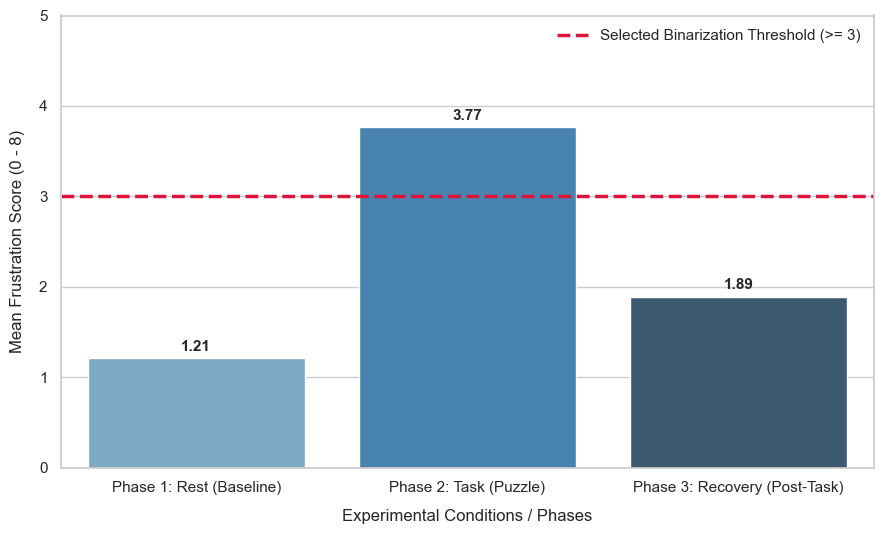

In [2]:
# 1. Load the dataset
# Make sure 'HR_data.csv' is in your working directory or provide the full path
df = pd.read_csv('HR_data.csv')

# 2. Clean and order the phases chronologically
phase_order = ['phase1', 'phase2', 'phase3']
df['Phase'] = pd.Categorical(df['Phase'], categories=phase_order, ordered=True)

# 3. Calculate descriptive statistics to reproduce the exact phase averages
phase_means = df.groupby('Phase')['Frustrated'].mean().reset_index()

# Map internal phase strings to clear, reader-friendly titles
phase_mapping = {
    'phase1': 'Phase 1: Rest (Baseline)',
    'phase2': 'Phase 2: Task (Puzzle)',
    'phase3': 'Phase 3: Recovery (Post-Task)'
}
phase_means['Phase_Label'] = phase_means['Phase'].map(phase_mapping)

print("="*50)
print("AVERAGE FRUSTRATION SCORES PER PHASE")
print("="*50)
for _, row in phase_means.iterrows():
    print(f"{row['Phase_Label']}: {row['Frustrated']:.2f}")
print("="*50)

# 4. Data Visualization: Bar Plot with Threshold Line
plt.figure(figsize=(9, 5.5))
sns.set_theme(style="whitegrid")

# Create the bar chart
ax = sns.barplot(
    data=phase_means, 
    x='Phase_Label', 
    y='Frustrated', 
    palette='Blues_d', 
    hue='Phase_Label',
    legend=False
)

# Plot a prominent horizontal line at our chosen threshold (3)
plt.axhline(
    y=3, 
    color='crimson', 
    linestyle='--', 
    linewidth=2.5, 
    label='Selected Binarization Threshold (>= 3)'
)

# Add annotations/labels above each bar dynamically
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}", 
        (p.get_x() + p.get_width() / 2., height), 
        ha='center', va='center', 
        xytext=(0, 8), 
        textcoords='offset points', 
        fontsize=11, fontweight='bold'
    )

# Chart styling and details
plt.xlabel('Experimental Conditions / Phases', fontsize=12, labelpad=10)
plt.ylabel('Mean Frustration Score (0 - 8)', fontsize=12, labelpad=10)
plt.ylim(0, 5)
plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()


### A quick check: could we have just done regression instead?

Out of curiosity, we also looked at how the raw `Frustrated` scores (0-8) are actually
distributed, since that's relevant to whether predicting the exact score (regression) would have
made more sense than predicting the binary label. It turns out the scores are heavily skewed
towards the low end, so a regression model would have very little to learn from in the upper half
of the scale, with only 14 individuals' worth of data to begin with.

Distribution of raw Frustrated scores (0-8), all 168 rows:
Frustrated
0    29
1    45
2    31
3    16
4    23
5    14
6     5
7     2
8     3
Name: count, dtype: int64

Median: 2.0
Mean:   2.29
Fraction of rows with Frustrated >= 6: 6.0%


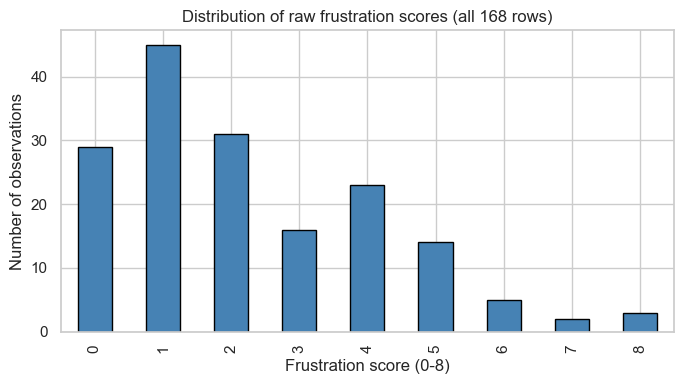

In [3]:
frustrated_counts = df['Frustrated'].value_counts().sort_index()
print("Distribution of raw Frustrated scores (0-8), all 168 rows:")
print(frustrated_counts)

print(f"\nMedian: {df['Frustrated'].median():.1f}")
print(f"Mean:   {df['Frustrated'].mean():.2f}")
print(f"Fraction of rows with Frustrated >= 6: {(df['Frustrated'] >= 6).mean():.1%}")

plt.figure(figsize=(7, 4))
frustrated_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Frustration score (0-8)')
plt.ylabel('Number of observations')
plt.title('Distribution of raw frustration scores (all 168 rows)')
plt.tight_layout()
plt.show()

## 1. Confusion matrices

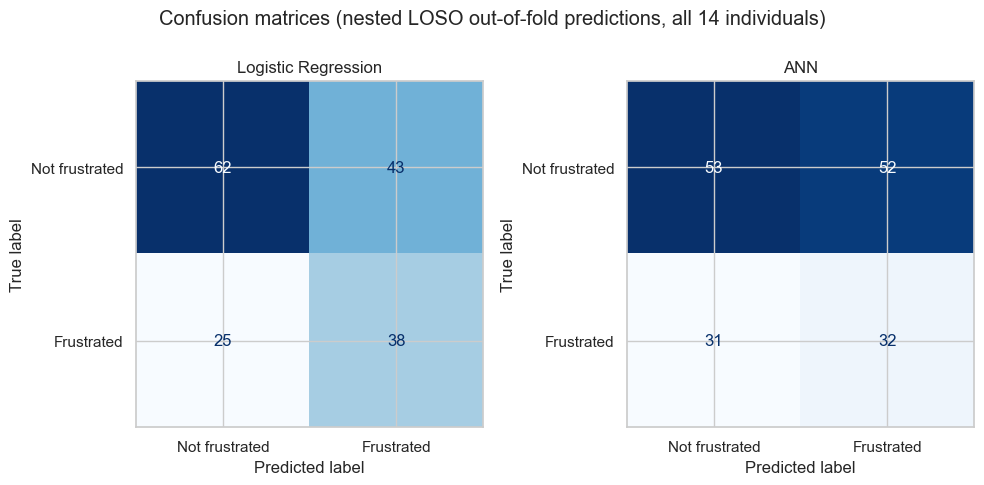

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["oof_true"], r["oof_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not frustrated", "Frustrated"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.suptitle("Confusion matrices (nested LOSO out-of-fold predictions, all 14 individuals)")
plt.tight_layout()
plt.show()

## 2. Summary metrics

In [5]:
rows = []
for name, r in results.items():
    y_true, y_pred, y_proba = r["oof_true"], r["oof_pred"], r["oof_proba"]
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], zero_division=0
    )
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Precision (Frustrated)": precision[0],
        "Recall (Frustrated)": recall[0],
        "F1 (Frustrated)": f1[0],
    })

summary_df = pd.DataFrame(rows).set_index("Model")
summary_df.round(3)

,Accuracy,Balanced accuracy,ROC-AUC,Precision (Frustrated),Recall (Frustrated),F1 (Frustrated)
Model,,,,,,
Logistic Regression,0.595,0.597,0.607,0.469,0.603,0.528
ANN,0.506,0.506,0.448,0.381,0.508,0.435


## 3. ROC curves

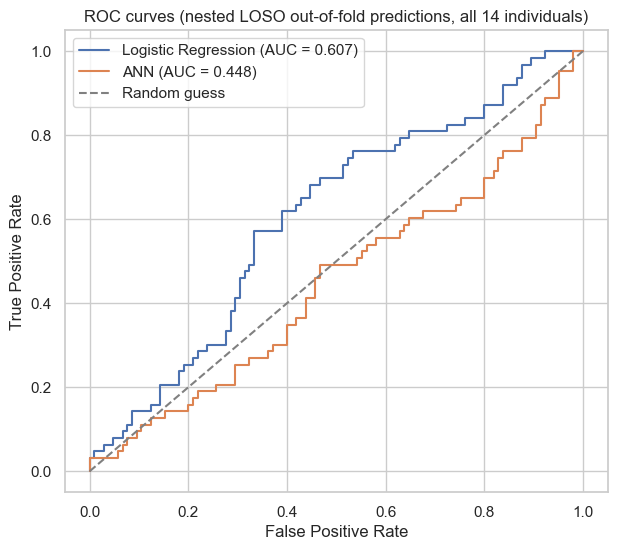

In [6]:
plt.figure(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r["oof_true"], r["oof_proba"])
    auc = roc_auc_score(r["oof_true"], r["oof_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (nested LOSO out-of-fold predictions, all 14 individuals)")
plt.legend()
plt.show()

## 4. Per-individual balanced accuracy

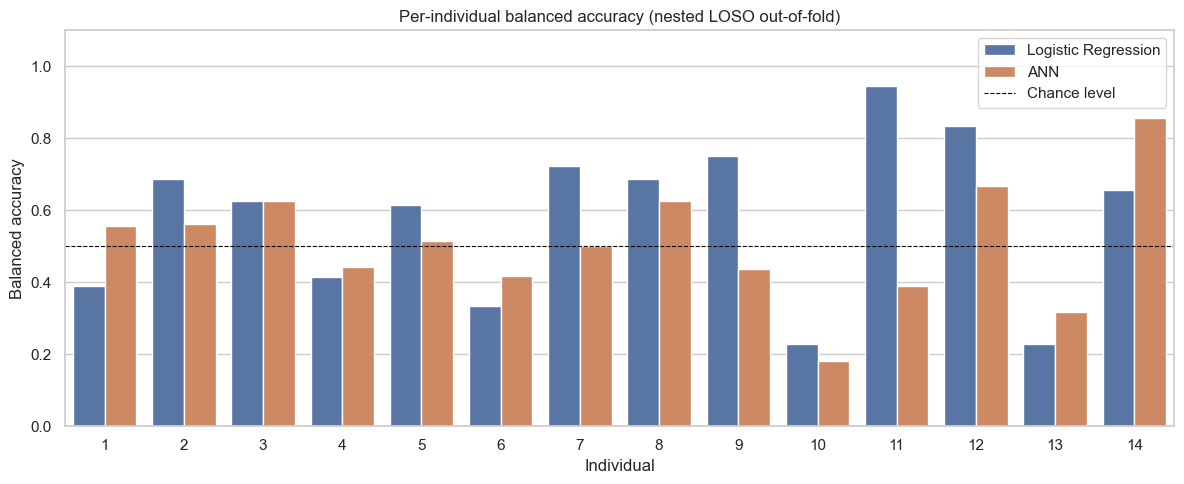

In [7]:
fold_long = pd.concat([
    pd.DataFrame({
        "Individual": r["fold_individual"],
        "Balanced accuracy": r["fold_balanced_accuracy"],
        "Model": name,
    })
    for name, r in results.items()
], ignore_index=True)

plt.figure(figsize=(12, 5))
sns.barplot(data=fold_long, x="Individual", y="Balanced accuracy", hue="Model")
plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="Chance level")
plt.title("Per-individual balanced accuracy (nested LOSO out-of-fold)")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Are the differences actually significant?

The summary metrics above are computed on the pooled 168 out-of-fold predictions, but each
individual contributes 12 of those rows, so they aren't independent observations - pooling them
overstates the effective sample size. A fairer comparison uses the 14 per-individual
balanced-accuracy scores instead (one per held-out individual, per model), which is naturally a
paired design since both models are scored on the same 14 people.

With only 14 individuals, and no real reason to assume the differences are normally distributed,
we used a paired Wilcoxon signed-rank test rather than a paired t-test.

In [8]:
from scipy.stats import wilcoxon
import itertools

# Per-individual balanced accuracy, aligned by Individual (paired design)
bal_acc_by_model = {
    name: pd.Series(r["fold_balanced_accuracy"], index=r["fold_individual"]).sort_index()
    for name, r in results.items()
}
aligned = pd.DataFrame(bal_acc_by_model)
print("Per-individual balanced accuracy:")
print(aligned.round(3))
print("\nMean per-individual balanced accuracy:")
print(aligned.mean().round(3))

print("\nPaired Wilcoxon signed-rank test on per-individual balanced accuracy:")
for m1, m2 in itertools.combinations(aligned.columns, 2):
    diff = aligned[m1] - aligned[m2]
    if (diff == 0).all():
        print(f"{m1} vs {m2}: identical per-individual scores (all 14 differences = 0)")
        continue
    stat, p = wilcoxon(aligned[m1], aligned[m2])
    print(f"{m1} vs {m2}: W = {stat:.3f}, p = {p:.3f}")

Per-individual balanced accuracy:
    Logistic Regression    ANN
1                 0.389  0.556
2                 0.688  0.562
3                 0.625  0.625
4                 0.414  0.443
5                 0.614  0.514
6                 0.333  0.417
7                 0.722  0.500
8                 0.688  0.625
9                 0.750  0.438
10                0.227  0.182
11                0.944  0.389
12                0.833  0.667
13                0.227  0.318
14                0.657  0.857

Mean per-individual balanced accuracy:
Logistic Regression    0.579
ANN                    0.507
dtype: float64

Paired Wilcoxon signed-rank test on per-individual balanced accuracy:
Logistic Regression vs ANN: W = 29.000, p = 0.249


## 6. So which model is better?

Both models are trained on the same fixed feature set: the 5 z-scored HR features (`HR_Mean`,
`HR_Median`, `HR_std`, `HR_Max`, `HR_AUC`; see `feature_correlation_analysis.ipynb` for why
`HR_Min` was dropped). `Phase` and `Round` are excluded -- see `robustness_checks.ipynb` Section 1:
when included, `Phase` dominates both models, which is suspicious since the frustration threshold
was itself picked using phase-level averages, so `Phase` was effectively encoding the label.

| Model | Accuracy | Balanced accuracy | ROC-AUC |
|---|---|---|---|
| Baseline (majority class) | 0.625 | 0.500 | 0.500 |
| Logistic Regression | 0.595 | 0.597 | 0.607 |
| ANN | 0.506 | 0.506 | 0.448 |

Neither model clearly beats the majority-class baseline. Logistic regression's balanced accuracy
and ROC-AUC sit a little above chance, while the ANN's barely move from 0.50, with its ROC-AUC
dipping below it -- likely reflecting the inner-loop hyperparameter search overfitting to noise
given how many parameters the ANN has relative to only 14 individuals.

The paired Wilcoxon test (Section 5) finds no significant difference between the two models
(p = 0.249, n = 14); `robustness_checks.ipynb` adds a bootstrap CI on the paired difference and a
McNemar cross-check, which lean towards a modest edge for logistic regression but aren't decisive
given the repeated-measures structure. Both models independently rank `HR_Mean` as the strongest
of the five HR features. Given the two models are statistically indistinguishable, logistic
regression is the more pragmatic choice in this small-sample context for its interpretability, but
the honest takeaway is that this dataset is too small and the signal too weak for either model to
demonstrate clear predictive value for frustration from heart rate alone.


## 7. Robustness checks (peer feedback follow-up)

The models above use only the five HR features (`Phase`/`Round` excluded -- see Section 1 of
`robustness_checks.ipynb` for why). That notebook also adds: a majority-class baseline, 95%
cluster-bootstrap confidence intervals on balanced accuracy for every model, a confidence interval
on the paired LogReg-ANN difference, a McNemar cross-check, and a sensitivity check on the
per-individual z-scoring. Short version: neither HR-only model clearly beats the majority-class
baseline, and adding `Phase`/`Round` back in lifts both models well above it -- confirming that
`Phase` was doing most of the work in the original full-feature run, which is why it was dropped
from the primary models reported here.